<a href="https://colab.research.google.com/github/MayerT1/LiDAR_Dev/blob/main/Covarite_Export_Sewanee_Pixel_FUSION_GEDI_RS_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

https://www.mdpi.com/2072-4292/13/3/442
https://iopscience.iop.org/article/10.1088/1748-9326/ab9e99/meta
https://dataverse.jpl.nasa.gov/file.xhtml?fileId=64312&version=3.0

https://www.neonscience.org/field-sites/guan
https://www.neonscience.org/field-sites/guan#field-site-data
https://data.neonscience.org/data-products/explore
https://data.neonscience.org/data-products/DP1.10098.001

https://lpdaac.usgs.gov/documents/980/gedi_l2b_dictionary_P003_v2.html

# Setup

In [1]:
!pip install gdal
!pip install laspy
!pip install lazrs
!pip install rasterio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.3/84.3 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 639.6/639.6 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.2/22.2 MB 75.4 MB/s eta 0:00:00


In [2]:
# Install necessary packages
!pip install geemap geopandas scikit-learn tensorflow

import ee
import geemap
import geopandas as gpd
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import SelectFromModel
import tensorflow as tf
from tensorflow.keras import layers, models


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 17.0 MB/s eta 0:00:00


In [3]:
# Authenticate and initialize Earth Engine
import ee
import geemap
import geemap.chart as chart
ee.Authenticate()
ee.Initialize(project='servir-sco-assets')
Map = geemap.Map()


In [4]:

from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


In [21]:
import os

# Define the base project folder and subdirectories
base_dir = '/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project'
subdirs = [
    'data',
    'models',
    'scripts',
    'notebooks',
    'config',
    'results'
]

# Create each subdirectory
for subdir in subdirs:
    path = os.path.join(base_dir, subdir)
    os.makedirs(path, exist_ok=True)
    print(f"Created: {path}")


Created: /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/data
Created: /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/models
Created: /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/scripts
Created: /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/notebooks
Created: /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/config
Created: /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/results


In [6]:
%cd /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project

/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project


In [7]:

s1Ascending_2021 = ee.Image("projects/servir-sco-assets/assets/Rx_Fire/EO_Outputs/Sewanee/s1Ascending_2021")
DEMindices_2021 = ee.Image("projects/servir-sco-assets/assets/Rx_Fire/EO_Outputs/Sewanee/s1Ascending_2021")
HLS_2021 = ee.Image("projects/servir-sco-assets/assets/Rx_Fire/EO_Outputs/Sewanee/HLS_2021")
LandsatComposite_2021 = ee.Image("projects/servir-sco-assets/assets/Rx_Fire/EO_Outputs/Sewanee/LandsatComposite_2021")
LandsatIndices_2021 = ee.Image("projects/servir-sco-assets/assets/Rx_Fire/EO_Outputs/Sewanee/LandsatIndices_2021")
S2Composite_2021 = ee.Image("projects/servir-sco-assets/assets/Rx_Fire/EO_Outputs/Sewanee/S2Composite_2021")
S2Indices_2021 = ee.Image("projects/servir-sco-assets/assets/Rx_Fire/EO_Outputs/Sewanee/S2Indices_2021")
landsatTasseledCapIndices_2021 = ee.Image("projects/servir-sco-assets/assets/Rx_Fire/EO_Outputs/Sewanee/landsatTasseledCapIndices_2021")
ROI = ee.FeatureCollection('projects/servir-sco-assets/assets/Rx_Fire/Vector_Data/Sewanee_Domain')
# GEDIindicesA_2021 = ee.Image("projects/servir-sco-assets/assets/Rx_Fire/EO_Outputs/Sewanee/GEDIindicesA_2021")
# GEDIindicesB_2021 = ee.Image("projects/servir-sco-assets/assets/Rx_Fire/EO_Outputs/Sewanee/GEDIindicesB_2021")

Map.addLayer(ROI, {}, 'ROI')
Map.addLayer(s1Ascending_2021, {}, 's1Ascending_2021')
Map.addLayer(DEMindices_2021, {}, 'DEMindices_2021')
# Map.addLayer(GEDIindicesA_2021, {}, 'GEDIindicesA_2021')
# Map.addLayer(GEDIindicesB_2021, {}, 'GEDIindicesB_2021')
Map.addLayer(HLS_2021, {}, 'HLS_2021')
Map.addLayer(LandsatComposite_2021, {}, 'LandsatComposite_2021')
Map.addLayer(LandsatIndices_2021, {}, 'LandsatIndices_2021')
Map.addLayer(S2Composite_2021, {}, 'S2Composite_2021')
Map.addLayer(S2Indices_2021, {}, 'S2Indices_2021')
Map.addLayer(landsatTasseledCapIndices_2021, {}, 'landsatTasseledCapIndices_2021')

stacked = s1Ascending_2021.addBands(DEMindices_2021).addBands(LandsatComposite_2021).addBands(LandsatIndices_2021).addBands(landsatTasseledCapIndices_2021).addBands(HLS_2021).addBands(S2Composite_2021).addBands(S2Indices_2021)

Map.addLayer(stacked, {}, 'stacked');

Map


Map(center=[0, 0], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=SearchDataGUI(childr…

#Spatial Autocorreltion Block

In [ ]:
# #//////////////////////////////////////////////////////////////////////////////////
# GEDIindicesA_2021 = ee.Image("projects/servir-sco-assets/assets/Rx_Fire/EO_Outputs/Sewanee/GEDIindicesA_2021")


# glad = ee.Image("projects/glad/GLCLU2020/Forest_height_2020").clip(ROI)
# Map.addLayer(glad, {}, "glad")
# glad = glad.gte(1).select(['b1']).rename(['class']);
# #print("glad", glad)

# classMask = GEDIindicesA_2021.addBands(glad)
# Map.addLayer(classMask, {}, "classMask")
# #print("classMask", classMask)


# proj = GEDIindicesA_2021.projection()
# grid = ROI.geometry().coveringGrid(proj, 30)
# grid = ee.FeatureCollection(grid).randomColumn("random", 42);
# #print("spatial_partition number of boxes in the grid", grid.size())
# val_samp = grid.filter('random <= 0.1').set("samp_type","val_samp");
# test_samp = grid.filter('random <= 0.3 and random >= 0.1').set("samp_type","test_samp");
# train_samp = grid.filter('random >= 0.3').set("samp_type","train_samp");


# #rint('val_samp 10%', val_samp.size());
# Map.addLayer(val_samp, {"color": "blue"}, "val_samp 10%")

# #print('test_samp 20%', test_samp.size());
# Map.addLayer(test_samp, {"color": "red"}, "test_samp 20%")

# #print('train_samp 70%', train_samp.size());
# Map.addLayer(train_samp, {"color": "green"}, "train_samp 70%")

# Map

In [ ]:
# import ee
# import geemap
# import numpy as np
# from tqdm import tqdm
# import os
# import json

# # ee.Initialize()

# # Load individual EO inputs (2021)
# s1Ascending_2021 = ee.Image("projects/servir-sco-assets/assets/Rx_Fire/EO_Outputs/Sewanee/s1Ascending_2021")
# DEMindices_2021 = ee.Image("projects/servir-sco-assets/assets/Rx_Fire/EO_Outputs/Sewanee/DEMindices_2021")
# HLS_2021 = ee.Image("projects/servir-sco-assets/assets/Rx_Fire/EO_Outputs/Sewanee/HLS_2021")
# LandsatComposite_2021 = ee.Image("projects/servir-sco-assets/assets/Rx_Fire/EO_Outputs/Sewanee/LandsatComposite_2021")
# LandsatIndices_2021 = ee.Image("projects/servir-sco-assets/assets/Rx_Fire/EO_Outputs/Sewanee/LandsatIndices_2021")
# landsatTasseledCapIndices_2021 = ee.Image("projects/servir-sco-assets/assets/Rx_Fire/EO_Outputs/Sewanee/landsatTasseledCapIndices_2021")
# S2Composite_2021 = ee.Image("projects/servir-sco-assets/assets/Rx_Fire/EO_Outputs/Sewanee/S2Composite_2021")
# S2Indices_2021 = ee.Image("projects/servir-sco-assets/assets/Rx_Fire/EO_Outputs/Sewanee/S2Indices_2021")

# # ROI
# ROI = ee.FeatureCollection('projects/servir-sco-assets/assets/Rx_Fire/Vector_Data/Sewanee_Domain')

# # Sampling Grid (based on one input image’s projection)
# scale = 10
# proj = LandsatComposite_2021.select(0).projection()
# grid = ROI.geometry().coveringGrid(proj, scale)
# grid = ee.FeatureCollection(grid).randomColumn("random", 42)

# # Partition
# val_samp = grid.filter('random <= 0.1')
# test_samp = grid.filter('random > 0.1 and random <= 0.3')
# train_samp = grid.filter('random > 0.3')

# # Optional: Downsample geometries for performance
# def sample_fc_randomly(fc, percent=0.1, seed=42):
#     fc = fc.randomColumn("rand", seed)
#     return fc.filter(ee.Filter.lt("rand", percent))

# SAMPLE_PERCENT = 0.0001
# train_samp = sample_fc_randomly(train_samp, SAMPLE_PERCENT)
# val_samp = sample_fc_randomly(val_samp, SAMPLE_PERCENT)
# test_samp = sample_fc_randomly(test_samp, SAMPLE_PERCENT)

# # Output directory on Google Drive
# data_dir = '/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/data'
# os.makedirs(data_dir, exist_ok=True)

# # Extract numpy arrays and geometry metadata
# def extract_numpy_with_geometry(image, fc, scale, name="set"):
#     bands = image.bandNames().getInfo()
#     features = fc.toList(fc.size())
#     arrays = []
#     metadata = []

#     for i in tqdm(range(fc.size().getInfo()), desc=f"{name} - {image.getInfo().get('id', 'image')}"):
#         try:
#             feat = ee.Feature(features.get(i))
#             geom = feat.geometry()
#             arr = geemap.ee_to_numpy(image, region=geom, scale=scale, bands=bands)

#             if arr is not None and arr.shape[0] > 0 and arr.shape[1] > 0:
#                 arrays.append(arr)
#                 metadata.append(geom.getInfo())
#         except Exception as e:
#             print(f"Skipped {name} tile {i}: {e}")
#             continue

#     return np.array(arrays), metadata

# # Save numpy and metadata
# def save_numpy_and_metadata(arrays, metadata, prefix):
#     npy_path = os.path.join(data_dir, f"{prefix}.npy")
#     meta_path = os.path.join(data_dir, f"{prefix}_geom.json")

#     np.save(npy_path, arrays)
#     with open(meta_path, 'w') as f:
#         json.dump(metadata, f)

#     print(f"Saved: {npy_path} and {meta_path}")

# # List of input sources
# input_images = {
#     "s1": s1Ascending_2021,
#     "dem": DEMindices_2021,
#     "hls": HLS_2021,
#     "landsat": LandsatComposite_2021,
#     "landsat_idx": LandsatIndices_2021,
#     "tcap": landsatTasseledCapIndices_2021,
#     "s2": S2Composite_2021,
#     "s2_idx": S2Indices_2021,
# }

# # Extract and save everything
# for key, img in input_images.items():
#     for split_name, fc in zip(["train", "val", "test"], [train_samp, val_samp, test_samp]):
#         arrays, metadata = extract_numpy_with_geometry(img, fc, scale, name=f"{key}_{split_name}")
#         save_numpy_and_metadata(arrays, metadata, prefix=f"{key}_{split_name}")


111111111111111111111111

tiling per proj scale of covariates

In [ ]:
# import ee
# import geemap
# import numpy as np
# from tqdm import tqdm
# import os
# import json

# # ee.Initialize()

# # Load EO Inputs
# input_images = {
#     "s1": ee.Image("projects/servir-sco-assets/assets/Rx_Fire/EO_Outputs/Sewanee/s1Ascending_2021"),
#     "dem": ee.Image("projects/servir-sco-assets/assets/Rx_Fire/EO_Outputs/Sewanee/DEMindices_2021"),
#     "hls": ee.Image("projects/servir-sco-assets/assets/Rx_Fire/EO_Outputs/Sewanee/HLS_2021"),
#     "landsat": ee.Image("projects/servir-sco-assets/assets/Rx_Fire/EO_Outputs/Sewanee/LandsatComposite_2021"),
#     "landsat_idx": ee.Image("projects/servir-sco-assets/assets/Rx_Fire/EO_Outputs/Sewanee/LandsatIndices_2021"),
#     "tcap": ee.Image("projects/servir-sco-assets/assets/Rx_Fire/EO_Outputs/Sewanee/landsatTasseledCapIndices_2021"),
#     "s2": ee.Image("projects/servir-sco-assets/assets/Rx_Fire/EO_Outputs/Sewanee/S2Composite_2021"),
#     "s2_idx": ee.Image("projects/servir-sco-assets/assets/Rx_Fire/EO_Outputs/Sewanee/S2Indices_2021"),
# }

# ROI = ee.FeatureCollection('projects/servir-sco-assets/assets/Rx_Fire/Vector_Data/Sewanee_Domain')

# # Sampling function
# def sample_fc_randomly(fc, percent=0.1, seed=42):
#     fc = fc.randomColumn("rand", seed)
#     return fc.filter(ee.Filter.lt("rand", percent))

# SAMPLE_PERCENT = 0.00001
# data_dir = '/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/data'
# os.makedirs(data_dir, exist_ok=True)

# def extract_and_save(image, fc, name, img_key):
#     proj = image.select(0).projection()
#     scale = proj.nominalScale().getInfo()
#     bands = image.bandNames().getInfo()
#     features = fc.toList(fc.size())
#     arrays = []
#     metadata = []

#     export_dir = os.path.join(data_dir, f"{img_key}_tiffs")
#     os.makedirs(export_dir, exist_ok=True)

#     for i in tqdm(range(fc.size().getInfo()), desc=f"{name} - {img_key}"):
#         try:
#             feat = ee.Feature(features.get(i))
#             geom = feat.geometry()
#             arr = geemap.ee_to_numpy(image, region=geom, scale=scale, bands=bands)

#             if arr is not None and arr.shape[0] > 0 and arr.shape[1] > 0:
#                 arrays.append(arr)
#                 metadata.append(geom.getInfo())

#                 # Export GeoTIFF
#                 file_path = os.path.join(export_dir, f"{name}_{i}.tif")
#                 geemap.ee_export_image(
#                     image.clip(geom),
#                     filename=file_path,
#                     scale=scale,
#                     region=geom,
#                     file_per_band=False
#                 )
#         except Exception as e:
#             print(f"Skipped {name} tile {i}: {e}")
#             continue

#     return np.array(arrays), metadata

# def save_numpy_and_metadata(arrays, metadata, prefix):
#     npy_path = os.path.join(data_dir, f"{prefix}.npy")
#     meta_path = os.path.join(data_dir, f"{prefix}_geom.json")

#     np.save(npy_path, arrays)
#     with open(meta_path, 'w') as f:
#         json.dump(metadata, f)

#     print(f"Saved: {npy_path} and {meta_path}")

# # Main export loop
# for key, img in input_images.items():
#     proj = img.select(0).projection()
#     scale = proj.nominalScale().getInfo()
#     grid = ROI.geometry().coveringGrid(proj, scale)
#     grid = ee.FeatureCollection(grid).randomColumn("random", 42)

#     val_samp = sample_fc_randomly(grid.filter('random <= 0.1'), SAMPLE_PERCENT)
#     test_samp = sample_fc_randomly(grid.filter('random > 0.1 and random <= 0.3'), SAMPLE_PERCENT)
#     train_samp = sample_fc_randomly(grid.filter('random > 0.3'), SAMPLE_PERCENT)

#     for split_name, fc in zip(["train", "val", "test"], [train_samp, val_samp, test_samp]):
#         arrays, metadata = extract_and_save(img, fc, name=f"{key}_{split_name}", img_key=key)
#         save_numpy_and_metadata(arrays, metadata, prefix=f"{key}_{split_name}")


2222222222222222222222222

In [ ]:
# import ee
# import geemap
# import numpy as np
# from tqdm import tqdm
# import os
# import json

# # ee.Initialize()

# # Load EO Inputs
# input_images = {
#     "s1": ee.Image("projects/servir-sco-assets/assets/Rx_Fire/EO_Outputs/Sewanee/s1Ascending_2021"),
#     "dem": ee.Image("projects/servir-sco-assets/assets/Rx_Fire/EO_Outputs/Sewanee/DEMindices_2021"),
#     "hls": ee.Image("projects/servir-sco-assets/assets/Rx_Fire/EO_Outputs/Sewanee/HLS_2021"),
#     "landsat": ee.Image("projects/servir-sco-assets/assets/Rx_Fire/EO_Outputs/Sewanee/LandsatComposite_2021"),
#     "landsat_idx": ee.Image("projects/servir-sco-assets/assets/Rx_Fire/EO_Outputs/Sewanee/LandsatIndices_2021"),
#     "tcap": ee.Image("projects/servir-sco-assets/assets/Rx_Fire/EO_Outputs/Sewanee/landsatTasseledCapIndices_2021"),
#     "s2": ee.Image("projects/servir-sco-assets/assets/Rx_Fire/EO_Outputs/Sewanee/S2Composite_2021"),
#     "s2_idx": ee.Image("projects/servir-sco-assets/assets/Rx_Fire/EO_Outputs/Sewanee/S2Indices_2021"),
# }

# ROI = ee.FeatureCollection('projects/servir-sco-assets/assets/Rx_Fire/Vector_Data/Sewanee_Domain')

# # Sampling function
# def sample_fc_randomly(fc, percent=0.1, seed=42):
#     fc = fc.randomColumn("rand", seed)
#     return fc.filter(ee.Filter.lt("rand", percent))

# SAMPLE_PERCENT = 0.0001
# data_dir = '/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/data'
# os.makedirs(data_dir, exist_ok=True)

# def extract_and_save(image, fc, name, img_key):
#     proj = image.select(0).projection()
#     scale = proj.nominalScale().getInfo()
#     bands = image.bandNames().getInfo()
#     features = fc.toList(fc.size())
#     arrays = []
#     metadata = []

#     export_dir = os.path.join(data_dir, f"{img_key}_tiffs")
#     os.makedirs(export_dir, exist_ok=True)

#     for i in tqdm(range(fc.size().getInfo()), desc=f"{name} - {img_key}"):
#         try:
#             feat = ee.Feature(features.get(i))
#             geom = feat.geometry()
#             arr = geemap.ee_to_numpy(image, region=geom, scale=scale, bands=bands)

#             if arr is not None and arr.shape[0] > 0 and arr.shape[1] > 0:
#                 arrays.append(arr)
#                 metadata.append(geom.getInfo())

#                 # Export GeoTIFF
#                 file_path = os.path.join(export_dir, f"{name}_{i}.tif")
#                 geemap.ee_export_image(
#                     image.clip(geom),
#                     filename=file_path,
#                     scale=scale,
#                     region=geom,
#                     file_per_band=False
#                 )
#         except Exception as e:
#             print(f"Skipped {name} tile {i}: {e}")
#             continue

#     return np.array(arrays), metadata

# def save_numpy_and_metadata(arrays, metadata, prefix):
#     npy_path = os.path.join(data_dir, f"{prefix}.npy")
#     meta_path = os.path.join(data_dir, f"{prefix}_geom.json")

#     np.save(npy_path, arrays)
#     with open(meta_path, 'w') as f:
#         json.dump(metadata, f)

#     print(f"Saved: {npy_path} and {meta_path}")

# # ==========================
# # ✅ FIXED GEOMETRIES HERE
# # ==========================
# # Use Landsat as reference projection
# reference_img = input_images["landsat"]
# proj = reference_img.select(0).projection()
# scale = proj.nominalScale().getInfo()

# # Create fixed sampling grid
# grid = ROI.geometry().coveringGrid(proj, scale)
# grid = ee.FeatureCollection(grid).randomColumn("random", 42)

# # Partition
# val_samp = sample_fc_randomly(grid.filter('random <= 0.1'), SAMPLE_PERCENT)
# test_samp = sample_fc_randomly(grid.filter('random > 0.1 and random <= 0.3'), SAMPLE_PERCENT)
# train_samp = sample_fc_randomly(grid.filter('random > 0.3'), SAMPLE_PERCENT)

# # Export loop (using the same geometries for each image)
# for key, img in input_images.items():
#     for split_name, fc in zip(["train", "val", "test"], [train_samp, val_samp, test_samp]):
#         arrays, metadata = extract_and_save(img, fc, name=f"{key}_{split_name}", img_key=key)
#         save_numpy_and_metadata(arrays, metadata, prefix=f"{key}_{split_name}")


333333333333333333333

In [51]:
# import ee

# # ee.Authenticate()
# ee.Initialize()

# === PARAMETERS ===
subsample_fraction = 0.20  # 1.0 = all, 0.2 = 20%
export_folder = 'PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/data'  # Google Drive folder path
grid_size = 320  # meters

# === Load ROI ===
ROI = ee.FeatureCollection('projects/servir-sco-assets/assets/Rx_Fire/Vector_Data/Sewanee_Domain')
roi_geom = ROI.geometry()

# === Covariates and their native resolution ===
covariates = {
    "s1": {"image": ee.Image("projects/servir-sco-assets/assets/Rx_Fire/EO_Outputs/Sewanee/s1Ascending_2021"), "scale": 10},
    "dem": {"image": ee.Image("projects/servir-sco-assets/assets/Rx_Fire/EO_Outputs/Sewanee/DEMindices_2021"), "scale": 30},
    "hls": {"image": ee.Image("projects/servir-sco-assets/assets/Rx_Fire/EO_Outputs/Sewanee/HLS_2021"), "scale": 30},
    "landsat": {"image": ee.Image("projects/servir-sco-assets/assets/Rx_Fire/EO_Outputs/Sewanee/LandsatComposite_2021"), "scale": 30},
    "landsat_idx": {"image": ee.Image("projects/servir-sco-assets/assets/Rx_Fire/EO_Outputs/Sewanee/LandsatIndices_2021"), "scale": 30},
    "tcap": {"image": ee.Image("projects/servir-sco-assets/assets/Rx_Fire/EO_Outputs/Sewanee/landsatTasseledCapIndices_2021"), "scale": 30},
    "s2": {"image": ee.Image("projects/servir-sco-assets/assets/Rx_Fire/EO_Outputs/Sewanee/S2Composite_2021"), "scale": 20},
    "s2_idx": {"image": ee.Image("projects/servir-sco-assets/assets/Rx_Fire/EO_Outputs/Sewanee/S2Indices_2021"), "scale": 20}
}

# === Create spatial sampling grid ===
grid = ee.FeatureCollection(roi_geom.coveringGrid("EPSG:3857", grid_size))

# === Add a random column for splitting ===
grid = grid.randomColumn('rand')

# === Assign tile IDs (fallback to centroid coords string if id is None) ===
def add_tile_id(feature):
    tile_id = feature.id()
    tile_id = ee.Algorithms.If(
        tile_id,
        tile_id,
        # fallback: join coords as "x_y"
        ee.String(ee.Number(feature.geometry().centroid().coordinates().get(0)).format('%.6f'))
        .cat('_')
        .cat(ee.Number(feature.geometry().centroid().coordinates().get(1)).format('%.6f'))
    )
    return feature.set({'tile_id': tile_id})

grid = grid.map(add_tile_id)

# === Partition ===
train_frac, val_frac = 0.6, 0.2
train_tiles = grid.filter(ee.Filter.lt("rand", train_frac))
val_tiles = grid.filter(ee.Filter.And(
    ee.Filter.gte("rand", train_frac),
    ee.Filter.lt("rand", train_frac + val_frac)
))
test_tiles = grid.filter(ee.Filter.gte("rand", train_frac + val_frac))

# === Optional subsampling ===
def subsample(fc, fraction):
    count = fc.size()
    sample_size = ee.Number(count).multiply(fraction).toInt()
    return fc.randomColumn('sub_rand').sort('sub_rand').limit(sample_size)

if subsample_fraction < 1.0:
    train_tiles = subsample(train_tiles, subsample_fraction)
    val_tiles = subsample(val_tiles, subsample_fraction)
    test_tiles = subsample(test_tiles, subsample_fraction)

splits = {
    "train": train_tiles,
    "val": val_tiles,
    "test": test_tiles
}

# === Count and print number of tiles to export ===
print("Export tile counts:")
for split_name, fc in splits.items():
    count = fc.size().getInfo()
    print(f"  {split_name}: {count} tiles to export (after subsampling {subsample_fraction * 100:.0f}%)")

# === Export function ===
def export_covariate_tiles(image_dict, cov_name, split_name, grid_fc):
    img = image_dict["image"].clip(roi_geom)
    scale = image_dict["scale"]

    def export_tile(feature):
        tile_id = feature.get("tile_id")
        tile_geom = feature.geometry()
        description = ee.String(f"{cov_name}_{split_name}_").cat(tile_id)
        file_prefix = description
        task = ee.batch.Export.image.toDrive(
            image=img,
            description=description.getInfo(),
            folder=export_folder,
            fileNamePrefix=file_prefix.getInfo(),
            region=tile_geom,
            scale=scale,
            crs="EPSG:32616",
            maxPixels=1e13
        )
        task.start()
        print(f"Started export: {description.getInfo()} at {scale}m")
        return feature

    features = grid_fc.getInfo()['features']
    for feat in features:
        ee_feat = ee.Feature(feat)
        export_tile(ee_feat)

# === Run exports ===
for cov_name, image_dict in covariates.items():
    for split_name, tile_fc in splits.items():
        export_covariate_tiles(image_dict, cov_name, split_name, tile_fc)


Export tile counts:
  train: 123 tiles to export (after subsampling 20%)
  val: 43 tiles to export (after subsampling 20%)
  test: 45 tiles to export (after subsampling 20%)
Started export: s1_train_-29901,13101 at 10m
Started export: s1_train_-29876,13091 at 10m
Started export: s1_train_-29884,13102 at 10m
Started export: s1_train_-29885,13092 at 10m
Started export: s1_train_-29892,13109 at 10m
Started export: s1_train_-29883,13104 at 10m
Started export: s1_train_-29884,13107 at 10m
Started export: s1_train_-29908,13100 at 10m
Started export: s1_train_-29876,13090 at 10m
Started export: s1_train_-29903,13107 at 10m
Started export: s1_train_-29910,13097 at 10m
Started export: s1_train_-29885,13067 at 10m
Started export: s1_train_-29911,13102 at 10m
Started export: s1_train_-29879,13095 at 10m
Started export: s1_train_-29895,13092 at 10m
Started export: s1_train_-29894,13080 at 10m
Started export: s1_train_-29898,13111 at 10m
Started export: s1_train_-29877,13087 at 10m
Started export: 

In [ ]:
https://drive.google.com/drive/folders/19ZbrTgWnZtHxIarDBixKFSFxCq8ZteqG?usp=sharing

viz

Shape of data: (10, 4, 4, 2)


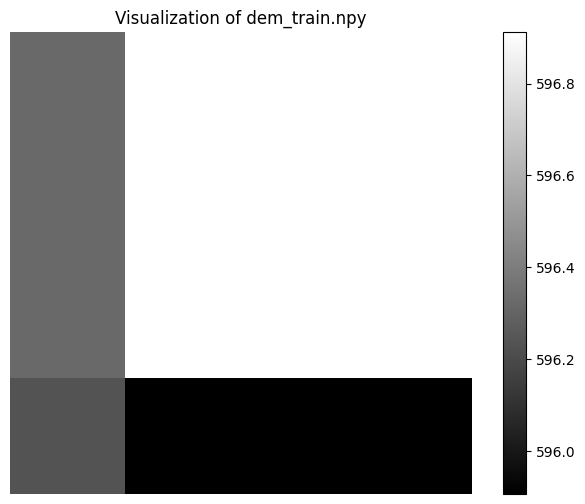

In [14]:
# import numpy as np
# import matplotlib.pyplot as plt

# # Load the .npy file
# file_path = '/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/data/dem_train.npy'
# data = np.load(file_path)

# # Print shape to understand what we're dealing with
# print("Shape of data:", data.shape)

# # Visualize depending on dimensions
# plt.figure(figsize=(8, 6))
# if data.ndim == 2:
#     plt.imshow(data, cmap='gray')
# elif data.ndim == 3 and data.shape[2] in [3, 4]:
#     plt.imshow(data[:, :, :3])
# elif data.ndim == 4:
#     # Show first band of the first sample
#     plt.imshow(data[0, :, :, 0], cmap='gray')
#     plt.title("First band of first sample (multi-band data)")
# else:
#     raise ValueError(f"Unsupported data shape: {data.shape}")

# plt.colorbar()
# plt.title("Visualization of dem_train.npy")
# plt.axis('off')
# plt.show()


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# Define a small Conv block
def conv_block(in_c, out_c):
    return nn.Sequential(
        nn.Conv2d(in_c, out_c, kernel_size=3, padding=1),
        nn.BatchNorm2d(out_c),
        nn.ReLU(),
        nn.Conv2d(out_c, out_c, kernel_size=3, padding=1),
        nn.BatchNorm2d(out_c),
        nn.ReLU(),
    )

# Each branch handles different resolutions
class EOBranch(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.encoder = conv_block(in_channels, out_channels)

    def forward(self, x, target_size):
        x = self.encoder(x)
        x = F.interpolate(x, size=target_size, mode="bilinear", align_corners=False)
        return x

class MultiResFusionModel(nn.Module):
    def __init__(self, channel_dict):
        super().__init__()
        self.branches = nn.ModuleDict({
            name: EOBranch(in_ch, 64) for name, in_ch in channel_dict.items()
        })
        self.fusion = conv_block(len(channel_dict) * 64, 128)
        self.regressor = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Linear(128, 1)
        )

    def forward(self, inputs):
        target_size = inputs["s1"].shape[-2:]  # Assume s1 is highest resolution
        feats = [branch(inputs[name], target_size) for name, branch in self.branches.items()]
        fused = self.fusion(torch.cat(feats, dim=1))
        return self.regressor(fused)

# Example usage
# Define input channel sizes
channel_dict = {
    "s1": 2,
    "s2": 12,
    "s2_idx": 5,
    "landsat": 6,
    "landsat_idx": 4,
    "tcap": 3,
    "hls": 5,
    "dem": 3
}

model = MultiResFusionModel(channel_dict)
example_input = {name: torch.randn(4, ch, 64 // (10 // res), 64 // (10 // res))
                 for name, (ch, res) in zip(channel_dict.keys(),
                                            [(channel_dict[k], 10 if 's1' in k or 's2' in k else 30)
                                             for k in channel_dict])}

out = model(example_input)
print(out.shape)  # should be [B, 1]
